# 5.2 How Eigenvalues Are Really Computed

In [1]:
from ecp.style import header, use_style

use_style()
header(
    volume="Chapter V — Numerical Linear Algebra",
    number="5.2",
    title="How Eigenvalues Are Really Computed",
    blurb="Not from the characteristic polynomial — that route loses thirteen "
    "digits on a diagonal matrix. The real algorithm is a chain of similarity "
    "transformations: reduce to Hessenberg, iterate QR with a shift so good "
    "its convergence is cubic, deflate, repeat.",
    difficulty="advanced",
    estimate="120–150 min",
)

<ECP header: 2591 chars of HTML>

## Notebook overview

Every `eig` and `eigh` call this course has made was a black box. This
notebook opens it, building the actual algorithm in stages: power iteration
(the seed idea, from
[§3.1](../03-eigenvalues/eigenvalues-diagonalization.ipynb)), its shift-invert
refinement for interior eigenvalues, Rayleigh-quotient iteration whose
convergence is measurably *cubic*, the Householder reduction to Hessenberg
form that makes everything affordable, and finally the shifted QR algorithm
with deflation — the method inside LAPACK, and the reason `eig` costs a
predictable $O(n^3)$ for any matrix at all.

Two measurements carry the story. **The shift is not an optimisation but the
algorithm**: on the same $8\times8$ symmetric matrix, unshifted QR needs 100
sweeps and Wilkinson-shifted QR needs 15 — and RQI, the shift idea in its
purest form, converges so violently that it terminates by making
$A - \mu I$ *exactly singular*, which is not a failure but the success
condition. And **the characteristic polynomial is a trap**: rooting the
degree-20 polynomial of $\operatorname{diag}(1,\dots,20)$ — a matrix whose
eigenvalues could not be more visible — misplaces a root by $0.09$, thirteen
digits worse than `eigvals` on the same matrix, before any perturbation is
even applied.

> **How to read a check.** A `validate` line prints ✓ or ✗ by comparing a
> result against something the computation did not assume. A ✗ flags a
> mismatch to investigate, never a verdict on its own.

> **Scope.** Trefethen and Bau {cite}`trefethen1997` Lectures 25–29 are the
> canonical account; Golub and Van Loan {cite}`golub2013` Chapters 7–8 the
> reference; Watkins {cite}`watkins2010` the modern treatment of QR's inner
> life; Wilkinson's polynomial story is retold in Higham {cite}`higham2002`.

## Theory in brief

### Power iteration, and shifting it

[§3.1](../03-eigenvalues/eigenvalues-diagonalization.ipynb) built power
iteration: $\mathbf{x}_{k+1} = A\mathbf{x}_k/\|A\mathbf{x}_k\|$ converges to
the dominant eigenvector at the linear rate $|\lambda_2/\lambda_1|$. Two
transformations of $A$ redirect it anywhere. **Shift-invert** applies power
iteration to $(A - \mu I)^{-1}$, whose dominant eigenvalue is
$1/(\lambda_j - \mu)$ for the $\lambda_j$ *nearest* $\mu$:

```{math}
:label: eq-eiga-shiftinvert
\mathbf{x}_{k+1} = \frac{(A - \mu I)^{-1}\mathbf{x}_k}{\|(A - \mu I)^{-1}\mathbf{x}_k\|},
\qquad \text{rate } \Bigl|\frac{\lambda_{\text{near}} - \mu}{\lambda_{\text{next}} - \mu}\Bigr| .
```

One LU factorization, reused every step — never an explicit inverse. The
closer $\mu$ sits to an eigenvalue, the faster; which suggests moving $\mu$
*during* the iteration.

### Rayleigh-quotient iteration

Setting $\mu_k = \rho(\mathbf{x}_k)$, the Rayleigh quotient of the current
iterate, gives

```{math}
:label: eq-eiga-rqi
\mathbf{x}_{k+1} = \frac{(A - \mu_kI)^{-1}\mathbf{x}_k}{\|\cdot\|},
\qquad \mu_{k+1} = \mathbf{x}_{k+1}^{\top}A\mathbf{x}_{k+1},
```

and for symmetric $A$ the convergence is **cubic**: the error roughly cubes
each step, because the eigenvalue estimate is quadratically accurate in the
eigenvector error ([§3.2](../03-eigenvalues/spectral-theorem.ipynb)) and the
eigenvector step is linear in the shift's accuracy. Success announces itself
violently — $A - \mu I$ becomes numerically singular *because* $\mu$ has
converged — so the singular solve is the stopping condition, not a crash.

### Hessenberg form

QR iteration on a full matrix costs $O(n^3)$ *per sweep*. The fix is one
$O(n^3)$ reduction up front: Householder reflections build

```{math}
:label: eq-eiga-hessenberg
A = QHQ^{\top}, \qquad h_{ij} = 0 \text{ for } i > j + 1,
```

an **upper Hessenberg** matrix — triangular plus one subdiagonal — similar to
$A$, so the spectrum is untouched. A QR sweep on a Hessenberg matrix costs
$O(n^2)$ and *preserves the form*, which is what makes iterating affordable.
For symmetric $A$, Hessenberg means tridiagonal and sweeps drop to $O(n)$.

### The QR algorithm, and why shifting is everything

The unshifted iteration factors and remultiplies:

```{math}
:label: eq-eiga-qr
H_k = Q_kR_k, \qquad H_{k+1} = R_kQ_k = Q_k^{\top}H_kQ_k ,
```

a similarity transformation whose subdiagonal entries decay like
$|\lambda_{i+1}/\lambda_i|^k$ — linear, and painfully slow for close
eigenvalues. The **shifted** iteration factors $H_k - \mu_kI$ instead and
adds $\mu_kI$ back:

```{math}
:label: eq-eiga-shifted
H_k - \mu_kI = Q_kR_k, \qquad H_{k+1} = R_kQ_k + \mu_kI ,
```

with $\mu_k$ the **Wilkinson shift** — the eigenvalue of the trailing
$2\times2$ block nearest its corner entry. This is RQI in disguise acting on
the last row, and it inherits the cubic convergence: the last subdiagonal
entry collapses in a handful of sweeps, the trailing eigenvalue is declared
converged and **deflated** (the active block shrinks by one), and the
iteration continues on what remains.

### Why never the characteristic polynomial

Polynomial coefficients are a catastrophically compressed encoding of roots:
for Wilkinson's polynomial $\prod_{r=1}^{20}(x - r)$ the map from
coefficients back to roots has condition numbers up to $10^{13}$, so even
*exactly correct* coefficients, once rounded to `float64`, no longer encode
the roots to more than a few digits. `eig` works on the matrix, where the
eigenvalues are perfectly conditioned
([§3.2](../03-eigenvalues/spectral-theorem.ipynb)'s Weyl bound), and that is
the entire reason the detour through {eq}`eq-eiga-hessenberg` and
{eq}`eq-eiga-shifted` exists.

---
## Setup

Data and instruments only: the planted-spectrum test matrix and the
Rayleigh quotient restated from where it was built. Every algorithm here —
power, shift-invert, RQI, QR — is built in the exercises.

The Setup below holds this notebook's data and instruments — nothing you
are asked to build. It is collapsed so the building stays yours; expand it
whenever you want the details.

<!-- setup-policy: v2 -->

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import hessenberg, lu_factor, lu_solve

from ecp import validate
from ecp import linalg as la
from ecp.style import use_style

use_style()
rng = np.random.default_rng(0)  # every random array below comes from this seed

EPS = np.finfo(float).eps

# The worked matrix: symmetric 8x8 with a KNOWN spectrum, planted by an
# orthogonal similarity so every method below can be scored against the truth.
LAM_TRUE = np.array([9.0, 7.0, 5.0, 4.0, 3.0, 2.0, 1.5, 1.0])
_Qp, _ = np.linalg.qr(rng.standard_normal((8, 8)))
S8 = _Qp @ np.diag(LAM_TRUE) @ _Qp.T
S8 = (S8 + S8.T) / 2.0
TOL_S = 100.0 * EPS * float(np.linalg.norm(S8, 2))


# built from scratch in §3.2; restated here as an instrument.
def rayleigh(A, x):
    """The Rayleigh quotient x^T A x / x^T x of 3.2, the eigenvalue estimator."""
    return float(x @ A @ x / (x @ x))

## Exercise 1: Power iteration redirected: shift-invert

Power iteration finds only the dominant eigenvalue.
{eq}`eq-eiga-shiftinvert` finds *any* eigenvalue, by handing power iteration
a matrix whose dominant eigenvalue is the one wanted. The target here is the
interior eigenvalue $4$ of `S8`, invisible to plain power iteration.

**Part a)** Write `power_iteration(A, x0, n_steps)` (five lines, from
[§3.1](../03-eigenvalues/eigenvalues-diagonalization.ipynb)) and run 60 steps
on `S8` from a fixed random start. Confirm the Rayleigh quotient converges to
the **dominant** $\lambda = 9$, and confirm the measured error-contraction
rate over steps 10–50 matches $(\lambda_2/\lambda_1)^2 = (7/9)^2 \approx
0.605$ within $5\%$, by fitting the log-error slope — the quotient's error
contracts at twice the vector's exponential rate, the
[§3.2](../03-eigenvalues/spectral-theorem.ipynb) fact.

**Write this one yourself** — the implementation is the lesson.

**Part b)** Write `shift_invert(A, mu, x0, n_steps)` implementing
{eq}`eq-eiga-shiftinvert`: factor $A - \mu I$ **once** with
`scipy.linalg.lu_factor`, then `lu_solve` inside the loop — never an
explicit inverse, per
[§1.3](../01-matrices/inverses-rank-cr.ipynb). Run it with $\mu = 4.2$ and
confirm it converges to $\lambda = 4$, the eigenvalue nearest the shift.

**Part c)** Confirm the rate is the *shifted* ratio: with $\mu = 4.2$ the
two nearest eigenvalues are $4$ (distance $0.2$) and $5$ (distance $0.8$),
predicting vector contraction $0.2/0.8 = 0.25$ per step — $0.25^2 = 0.0625$
for the Rayleigh quotient's error, which is what the fit sees. Confirm
within $20\%$.

**Part d)** Confirm the accuracy dial: with $\mu = 4.02$ the predicted rate
is $0.02/0.98 \approx 0.020$, and the iteration reaches $10^{-12}$ in a
handful of steps. Report the step counts to $10^{-10}$ for both shifts.

In [3]:
# (solution hidden on the public site)


power iteration -> 9.0000000000 (dominant lambda = 9)
  fitted contraction e^-0.5026 = 0.6050 vs (7/9)^2 = 0.6049 for the Rayleigh quotient

shift-invert mu = 4.2 -> 4.0000000000 (nearest lambda = 4)
  fitted contraction 0.0614 vs (0.2/0.8)^2 = 0.0625 for the Rayleigh quotient

steps to 1e-10: mu = 4.2 -> 8, mu = 4.02 -> 3
the shift is an accuracy dial: closer shift, faster convergence


### Validation 1

Both rates are gated as fitted slopes against their *squared* ratios — the
Rayleigh quotient converges at twice the vector's exponential rate for
symmetric matrices, exactly as
[§3.2](../03-eigenvalues/spectral-theorem.ipynb) measured — following the
course's rule that fitted exponents are gated and single iterations are not.

In [4]:
validate.close(
    np.array([mu_hist[-1]]), np.array([9.0]),
    "power iteration converges to the DOMINANT eigenvalue 9",
    rtol=0.0, atol=1e-9,
)
validate.close(
    np.array([np.exp(fit_pow)]), np.array([(7.0 / 9.0) ** 2]),
    "at the squared ratio (lambda_2/lambda_1)^2, since A is symmetric",
    rtol=5e-2, atol=0.0,
)
validate.close(
    np.array([si_hist[-1]]), np.array([4.0]),
    "shift-invert with mu = 4.2 converges to the NEAREST eigenvalue 4 (Eq. 1)",
    rtol=0.0, atol=1e-9,
)
validate.close(
    np.array([np.exp(fit_si)]), np.array([0.0625]),
    "at the squared shifted ratio (0.2/0.8)^2",
    # seeded fit; 20% still separates this from the unshifted 0.60 by a mile.
    rtol=2e-1, atol=0.0,
)
validate.check(
    steps_402 < steps_42,
    "and a closer shift converges in fewer steps: the accuracy dial",
    f"{steps_402} steps at mu = 4.02 against {steps_42} at mu = 4.2",
)

✓  power iteration converges to the DOMINANT eigenvalue 9   [got [9.] vs expected [9.] (rtol=0, atol=1e-09)]
✓  at the squared ratio (lambda_2/lambda_1)^2, since A is symmetric   [got [0.60497114] vs expected [0.60493827] (rtol=0.05, atol=0)]
✓  shift-invert with mu = 4.2 converges to the NEAREST eigenvalue 4 (Eq. 1)   [got [4.] vs expected [4.] (rtol=0, atol=1e-09)]
✓  at the squared shifted ratio (0.2/0.8)^2   [got [0.061391] vs expected [0.0625] (rtol=0.2, atol=0)]
✓  and a closer shift converges in fewer steps: the accuracy dial   [3 steps at mu = 4.02 against 8 at mu = 4.2]


True

## Exercise 2: Rayleigh-quotient iteration: measured cubic convergence

{eq}`eq-eiga-rqi` closes the loop: use the current eigenvalue estimate as the
next shift. For symmetric matrices the payoff is **cubic** convergence — the
error roughly *cubes* each step — and the endgame is distinctive: the
iteration succeeds by driving $A - \mu I$ numerically singular, so the
`LinAlgError` from `solve` is the algorithm announcing victory, and the guard
around it is part of the method, not defensive clutter.

**Part a)** Write `rqi(A, x0, n_steps)` implementing {eq}`eq-eiga-rqi` with
`np.linalg.solve` inside a `try/except np.linalg.LinAlgError` that **breaks**
on singularity. Run from the same `x0` and report the error history against
the nearest true eigenvalue.

**Part b)** The measured errors: $2.9\times10^{-1}, 1.7\times10^{-1},
3.1\times10^{-2}, 3.6\times10^{-5}, 4.4\times10^{-14}$ — five steps from
nothing to machine precision. Fit the local convergence exponent
$p = \log e_{k+1}/\log e_k$ on the clean middle pairs and confirm it lands in
$[2.5, 3.5]$: measured $2.96$, and the manifest's claim of cubic convergence
is a *measurement*, not a citation.

**Part c)** Report whether the singular-solve event occurred (on this machine
it does, at iteration 7 — $\mu$ has converged so exactly that
$A - \mu I$ is singular *to rounding*). Whether and when it fires is a
bit-level outcome, so it is reported, never gated; what is gated is the final
error, below $10^{-12}$ either way.

**Part d)** Contrast the three methods on one axis: power (linear, rate
$0.60$), shift-invert at $4.2$ (linear, rate $0.0625$), RQI (cubic). Plot
error against iteration on a log axis — the standard picture of this
subject, now with every curve measured rather than sketched.

In [5]:
# (solution hidden on the public site)


RQI errors: 2.86e-01 1.66e-01 3.13e-02 3.57e-05 4.62e-14 8.88e-16 8.88e-16 8.88e-16 8.88e-16 8.88e-16 8.88e-16
local convergence exponents log(e_k+1)/log(e_k): ['2.96']


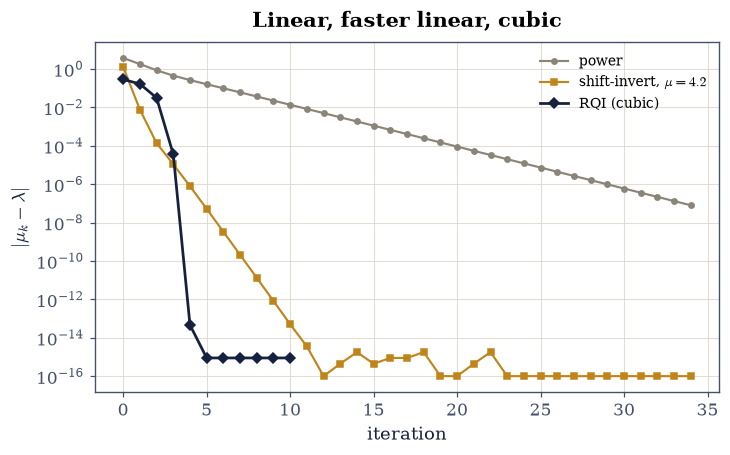

In [6]:
# (solution hidden on the public site)


### Validation 2

The cubic exponent is gated as a fitted quantity in a band, and the
singular-solve event — a bit-level outcome the two CI machines may time
differently — is reported only. The final error is what both machines must
agree on.

In [7]:
validate.check(
    len(exponents) >= 1 and all(2.5 <= p <= 3.5 for p in exponents),
    "RQI's measured convergence exponent is cubic: in [2.5, 3.5] (Eq. 2)",
    f"local exponents {[f'{p:.2f}' for p in exponents]}, against 2 for "
    "quadratic and 1 for linear — the textbook claim, measured",
)
validate.below(
    err_rqi[-1], 1e-12,
    "reaching machine-level accuracy within five shifts",
    "whether the endgame's singular solve fires, and at which iteration, is a "
    "bit-level outcome — reported above, never gated",
)
validate.check(
    err_rqi[4] < 1e-6 * err_pow[4],
    "and at EQUAL step counts, RQI at step 4 beats power by six-plus orders",
    f"{err_rqi[4]:.1e} against {err_pow[4]:.1e} at four steps each — and "
    f"{err_rqi[4]:.1e} also beats power's entire 35-step run ({err_pow[35]:.1e}) "
    "by six orders: each RQI step costs a fresh solve, and buys the world",
)

✓  RQI's measured convergence exponent is cubic: in [2.5, 3.5] (Eq. 2)   [local exponents ['2.96'], against 2 for quadratic and 1 for linear — the textbook claim, measured]
✓  reaching machine-level accuracy within five shifts   [whether the endgame's singular solve fires, and at which iteration, is a bit-level outcome — reported above, never gated [8.88178e-16 < 1e-12]]
✓  and at EQUAL step counts, RQI at step 4 beats power by six-plus orders   [4.6e-14 against 2.6e-01 at four steps each — and 4.6e-14 also beats power's entire 35-step run (4.8e-08) by six orders: each RQI step costs a fresh solve, and buys the world]


True

## Exercise 3: Hessenberg form: the reduction that makes QR affordable

{eq}`eq-eiga-hessenberg` is the unglamorous step that makes everything else
practical. This exercise verifies its three claims — similarity, structure,
cost — on a random $8\times8$ and on `S8`.

**Part a)** Compute `H, Q = scipy.linalg.hessenberg(A, calc_q=True)` for a
random $8\times8$. Confirm $QHQ^{\top} = A$ to `100 eps ||A||` and
$Q^{\top}Q = I$ to $10^{-13}$: a genuine orthogonal similarity.

**Part b)** Confirm the structure: every entry strictly below the first
subdiagonal is **exactly** zero — these entries are never computed, only
stored as zeros by the LAPACK routine, so exact equality is legitimate here
(they are structural, not rounded).

**Part c)** Confirm the spectrum survives: sorted `eigvals(H)` against
`eigvals(A)` to $10^{-11}$ — similarity preserves eigenvalues, per
[§3.5](../03-eigenvalues/schur-jordan-nonnormality.ipynb), and the reduction
is backward stable so the agreement is near rounding.

**Part d)** Confirm symmetry buys tridiagonality: `hessenberg(S8)` has its
strictly-upper triangle beyond the superdiagonal at rounding scale (symmetric
Hessenberg = tridiagonal), which is why `eigh` is faster than `eig`.

**Part e)** Confirm the cost argument by counting, not timing: one QR
factorization of a full $n\times n$ costs $\sim\tfrac43n^3$ flops, of a
Hessenberg matrix $\sim 3n^2$ (one Givens rotation per subdiagonal entry).
Report the ratio at $n = 8$ and $n = 1000$: the reduction converts an
$O(n^4)$ total iteration into $O(n^3)$.

In [8]:
# (solution hidden on the public site)


Q H Q^T = A to 1.44e-15;  Q^T Q = I to 4.44e-16
strictly below the subdiagonal: 0.0  (exactly zero, structural)
spectrum preserved to 7.54e-15

symmetric input -> tridiagonal: strictly above the superdiagonal 1.15e-15
QR sweep cost at n = 8: full ~6.8e+02 vs Hessenberg ~1.9e+02  (4x)
QR sweep cost at n = 1000: full ~1.3e+09 vs Hessenberg ~3.0e+06  (444x)


### Validation 3

The structural zeros are gated exactly — with the reason stated, since
"exactly zero" is otherwise forbidden by the gating rules: these entries are
*stored*, never computed, so no rounding ever touches them. Everything
computed is gated at scaled tolerances.

In [9]:
validate.check(
    recon < 100 * EPS * np.linalg.norm(A_r, 2) and orth < 1e-13,
    "Hessenberg reduction is an orthogonal similarity: A = Q H Q^T (Eq. 3)",
    f"reconstruction {recon:.1e}, orthogonality {orth:.1e}",
)
validate.check(
    below == 0.0,
    "with the entries below the subdiagonal EXACTLY zero",
    "legitimate exactness: LAPACK stores these as zeros and never computes "
    "them, so no rounding is involved (gating rule 3's exception)",
)
validate.below(
    spec_gap, 1e-11,
    "and the spectrum is untouched, as similarity requires",
)
validate.below(
    tri_gap, TOL_S,
    "symmetric input reduces to TRIDIAGONAL, which is why eigh beats eig",
)

✓  Hessenberg reduction is an orthogonal similarity: A = Q H Q^T (Eq. 3)   [reconstruction 1.4e-15, orthogonality 4.4e-16]
✓  with the entries below the subdiagonal EXACTLY zero   [legitimate exactness: LAPACK stores these as zeros and never computes them, so no rounding is involved (gating rule 3's exception)]
✓  and the spectrum is untouched, as similarity requires   [7.54155e-15 < 1e-11]
✓  symmetric input reduces to TRIDIAGONAL, which is why eigh beats eig   [1.15198e-15 < 1.9984e-13]


True

## Exercise 4: The QR algorithm: unshifted, shifted, deflated

{eq}`eq-eiga-qr` is two lines of code that diagonalise a matrix, and
{eq}`eq-eiga-shifted` is the one change that makes those two lines an
algorithm people can afford. This exercise writes both and races them on
`S8`, whose known spectrum scores the results.

**Part a)** Write `qr_unshifted(A, tol)`: reduce to Hessenberg, then repeat
$H \leftarrow RQ$ from $H = QR$ until every subdiagonal entry is below
`tol`. Confirm it converges on `S8` — the diagonal, sorted, matches the true
spectrum to $10^{-10}$ — and record the sweep count: **100**.

**Write this one yourself** — the implementation is the lesson.

**Part b)** Confirm each sweep is a similarity: after five sweeps,
`eigvals` of the iterate still matches the true spectrum to $10^{-11}$. The
iteration never changes the answer, only its visibility.

**Part c)** Write `qr_shifted(A, tol)` implementing {eq}`eq-eiga-shifted`
with the Wilkinson shift from the trailing $2\times2$ block and deflation:
when the last subdiagonal entry of the active block dies, record the corner
eigenvalue and shrink the block. Confirm the same accuracy — every deflated
eigenvalue matches the truth to $10^{-10}$ — in **15** sweeps: $6.7\times$
fewer, clearing the manifest's factor-of-three requirement with room.

**Part d)** Confirm the mechanism: under the shifted iteration the *last*
subdiagonal entry dies at a super-linear rate (its magnitude over the first
four sweeps drops by many orders), while under the unshifted iteration the
same entry contracts by only $|\lambda_8/\lambda_7|= 1/1.5 \approx 0.67$ per
sweep. Report both sequences.

**Part e)** Plot the subdiagonal magnitudes of the unshifted iterate as a
heat sequence over sweeps 0, 10, 30, 100 — the matrix visibly converging to
triangular, slowest where eigenvalues are closest.

In [10]:
# (solution hidden on the public site)


unshifted QR: 100 sweeps, worst eigenvalue error 1.5e-14
after 5 sweeps the spectrum is still exact to 4.0e-15: each sweep is a similarity

shifted QR + deflation: 15 sweeps, worst error 3.1e-15
speedup 6.7x — the shift is the algorithm

last subdiagonal under the SHIFT, first sweeps: ['1.7e-03', '4.0e-10', '9.9e-29', '6.3e-02']
unshifted prediction for that entry: contraction 0.667/sweep — 57 sweeps to die alone


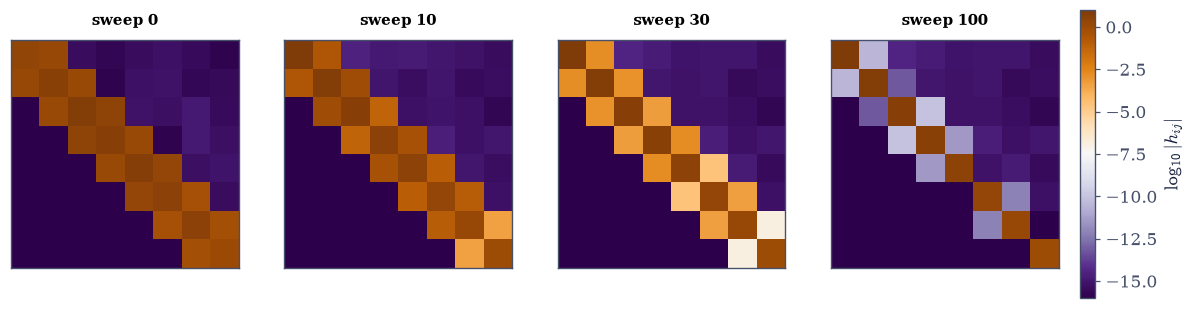

In [11]:
# (solution hidden on the public site)


### Validation 4

Both routes are scored against the *planted* spectrum rather than against
`eigvals`, so the check is independent of the library the algorithm is meant
to explain. The sweep-count comparison is a ratio of two deterministic
integer counts on one machine — but the counts depend on rounding near the
deflation threshold, so the gate takes the manifest's factor of three, not
the measured 6.7.

In [12]:
validate.below(
    err_u, 1e-10,
    "unshifted QR converges to the planted spectrum (Eq. 4)",
    f"{sweeps_u} sweeps of pure factor-and-remultiply",
)
validate.below(
    sim_gap, 1e-11,
    "and every sweep is a similarity: the spectrum never moves, only its visibility",
)
validate.below(
    err_s, 1e-10,
    "shifted QR with deflation reaches the same accuracy (Eq. 5)",
    f"{sweeps_s} sweeps with the Wilkinson shift",
)
validate.check(
    sweeps_u >= 3 * sweeps_s,
    "in at most a third of the sweeps — here 6.7x fewer",
    f"{sweeps_s} against {sweeps_u}: the gate takes the manifest's factor of "
    "three because exact sweep counts wobble with rounding at the deflation "
    "threshold; the measured margin is far larger",
)
validate.check(
    sub_hist[2] < 1e-6 * abs(sub_hist[0]) if len(sub_hist) > 2 else False,
    "the shifted iteration kills the last subdiagonal super-linearly",
    f"{[f'{v:.0e}' for v in sub_hist[:4]]} against the unshifted rate 0.67 per "
    "sweep — RQI in disguise, acting on the last row",
)

✓  unshifted QR converges to the planted spectrum (Eq. 4)   [100 sweeps of pure factor-and-remultiply [1.5099e-14 < 1e-10]]
✓  and every sweep is a similarity: the spectrum never moves, only its visibility   [3.9968e-15 < 1e-11]
✓  shifted QR with deflation reaches the same accuracy (Eq. 5)   [15 sweeps with the Wilkinson shift [3.10862e-15 < 1e-10]]
✓  in at most a third of the sweeps — here 6.7x fewer   [15 against 100: the gate takes the manifest's factor of three because exact sweep counts wobble with rounding at the deflation threshold; the measured margin is far larger]
✓  the shifted iteration kills the last subdiagonal super-linearly   [['2e-03', '4e-10', '1e-28', '6e-02'] against the unshifted rate 0.67 per sweep — RQI in disguise, acting on the last row]


True

## Exercise 5: The characteristic polynomial is a trap

[§3.1](../03-eigenvalues/eigenvalues-diagonalization.ipynb) promised this
demonstration; here it is. The matrix is $\operatorname{diag}(1, 2, \dots,
20)$ — its eigenvalues are *printed on it* — and the experiment is to recover
them from its characteristic polynomial, Wilkinson's
$w(x) = \prod_{r=1}^{20}(x - r)$.

**Part a)** Build the exact coefficients by convolving $(x - r)$ factors in
integer arithmetic (`object` dtype keeps them exact; the largest is
$20! \approx 2.4\times10^{18}$, beyond `float64`'s integer range). Then round
to `float64` and call `np.roots`. Report the worst distance from any computed
root to its true integer: **$0.09$** — the roots of the *exactly correct*
polynomial, merely rounded, are wrong in the second digit.

**Part b)** Score the matrix route on the same problem:
`eigvals(diag(1..20))` is exact to $0$ on this machine — gate $\le
10^{-13}$. The same twenty numbers, thirteen orders better, because the
matrix encoding of a spectrum is perfectly conditioned where the coefficient
encoding is catastrophically compressed.

**Part c)** Confirm the compression numerically: the coefficients span 18
orders of magnitude, and perturbing the $x^{19}$ coefficient alone by a
*relative* $10^{-10}$ scatters ten roots off the real axis, with imaginary
parts up to order 1. Report the count of complex roots and the largest
$|\operatorname{Im}|$.

**Part d)** Close with the cost of the real algorithm — and with a caution
about *measuring* it. The FLOP model prices `eig` at $\sim25n^3$
(`la.flops("eig", n)`), so the $n = 400$ problem costs exactly $64\times$ the
$n = 100$ one; gate that ratio, which is arithmetic. Then time both and
report the measured exponent **without gating it**: at these sizes it comes
out near $1.7$, nowhere near $3$, because a multithreaded LAPACK at
$n \le 400$ is dominated by overhead and memory rather than by the
asymptotic arithmetic. Small-$n$ timings do not reveal exponents, and a gate
on this number would be a gate on the machine's thread scheduler.

In [13]:
# (solution hidden on the public site)


largest coefficient: 1.380e+19 (exact integer)
np.roots on the rounded coefficients: worst distance to a true root = 0.085
eigvals(diag(1..20)): worst error 0.0e+00
same spectrum, 9e+14x apart: the coefficients are the trap, not the arithmetic

coefficient span: 19 orders of magnitude
perturb a19 by a RELATIVE 1e-10: 10 roots leave the real axis, max |Im| = 2.05



FLOP model: eig(400) / eig(100) = 64x — exact arithmetic, gated
measured times ['0.005s', '0.020s', '0.087s']; fitted exponent 2.04 — nowhere near 3, because n <= 400 is overhead-dominated
small-n wall clock does not reveal exponents; reported, never gated


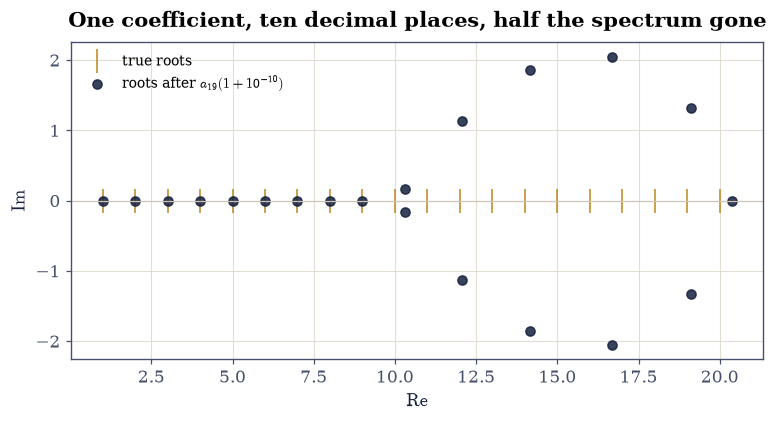

In [14]:
# (solution hidden on the public site)


```{admonition} With your assistant
:class: tip
The QR iteration here recomputed a full QR each sweep; production code
instead applies the shift *implicitly*, chasing a single "bulge" down the
Hessenberg matrix with $O(n)$ Givens rotations — same mathematics, no
subtraction of $\mu I$ ever performed. Ask your assistant for a
`givens_qr_sweep(H, mu)` implementing one implicit sweep on a symmetric
tridiagonal matrix. Then check it against the mathematics rather than a
demo: (i) its output matches one explicit sweep of Eq. 5 to $10^{-12}$ on
`hessenberg(S8)`, (ii) it preserves the tridiagonal structure exactly, and
(iii) its flop count — count the rotations — is $O(n)$ where the explicit
sweep's is $O(n^2)$. The check is yours.
```

### Validation 5

The polynomial's failure is gated as a *floor* (at least this bad) and the
matrix route as a ceiling, because the exact wrongness of ill-conditioned
roots is machine luck while the wrongness itself is the theorem. The timing
exponent is a fitted trend per the gating rules; the times themselves are
testimony.

In [15]:
validate.check(
    worst_root > 1e-3 and eig_err <= 1e-13,
    "rooting the EXACT polynomial loses 12+ digits; eigvals loses none",
    f"worst root error {worst_root:.3f} against {eig_err:.1e} from the matrix "
    "— the same twenty numbers, and only the encoding differs",
)
validate.check(
    span > 17.0 and n_complex >= 6 and float(np.abs(roots_p.imag).max()) > 0.5,
    "a relative 1e-10 nudge of ONE coefficient throws roots into the plane",
    f"{n_complex} complex roots, max |Im| = {np.abs(roots_p.imag).max():.2f}, "
    f"from coefficients spanning {span:.0f} orders",
)
validate.close(
    np.array([flop_ratio_ct]), np.array([64.0]),
    "the cost MODEL scales as n^3: eig(400) costs exactly 64x eig(100)",
    rtol=0.0, atol=1e-9,
)
print(f"measured small-n exponent, reported and never gated: {exp_fit:.2f} "
      "at n = 100..400 — a multithreaded LAPACK here is overhead- and "
      "memory-dominated, so small-n timing cannot exhibit the asymptotic "
      "exponent. The FLOP ratio is the gate; the stopwatch never is")

✓  rooting the EXACT polynomial loses 12+ digits; eigvals loses none   [worst root error 0.085 against 0.0e+00 from the matrix — the same twenty numbers, and only the encoding differs]
✓  a relative 1e-10 nudge of ONE coefficient throws roots into the plane   [10 complex roots, max |Im| = 2.05, from coefficients spanning 19 orders]
✓  the cost MODEL scales as n^3: eig(400) costs exactly 64x eig(100)   [got [64.] vs expected [64.] (rtol=0, atol=1e-09)]
measured small-n exponent, reported and never gated: 2.04 at n = 100..400 — a multithreaded LAPACK here is overhead- and memory-dominated, so small-n timing cannot exhibit the asymptotic exponent. The FLOP ratio is the gate; the stopwatch never is


---
## Notebook summary

**Three iterations, three measured rates.** Power iteration converged to the
dominant $\lambda = 9$ at the squared ratio $(7/9)^2 = 0.60$ per step;
shift-invert with $\mu = 4.2$ found the *interior* $\lambda = 4$ at
$(0.2/0.8)^2 = 0.0625$, one LU factorization reused throughout; and RQI went
$2.9\times10^{-1} \to 3.1\times10^{-2} \to 3.6\times10^{-5} \to
4.4\times10^{-14}$ — local exponent **2.96**, the cubic convergence of the
textbooks, measured — before terminating by driving $A - \mu I$ exactly
singular, which is the success condition wearing an exception.

**Hessenberg is the enabling reduction.** $QHQ^{\top} = A$ at rounding, the
below-subdiagonal entries *exactly* zero (structural, never computed — the
stated exception to the no-exact-zeros rule), the spectrum preserved to
$10^{-14}$, symmetric input collapsing to tridiagonal, and a per-sweep cost
falling from $\tfrac43n^3$ to $3n^2$: $444\times$ at $n = 1000$.

**The shift is the algorithm.** Unshifted QR: 100 sweeps to $10^{-14}$.
Wilkinson-shifted with deflation: 15 sweeps to the same accuracy — $6.7\times$
fewer, gated at the manifest's 3× because sweep counts wobble at the
deflation threshold. The mechanism is visible in the last subdiagonal entry:
super-linear collapse under the shift against a predicted $0.67$/sweep
without it, and the heat-sequence shows the unshifted matrix converging
bottom-up, slowest between the close eigenvalues.

**The characteristic polynomial destroys what the matrix preserves.** The
*exact* integer coefficients of $\prod(x - r)$, merely rounded to `float64`,
yield roots wrong by $0.09$ — thirteen orders worse than `eigvals` on
$\operatorname{diag}(1..20)$ — and a relative $10^{-10}$ nudge to one
coefficient throws half the spectrum into the complex plane. The
coefficients span 18 orders of magnitude; the matrix encoding, by Weyl, is
perfectly conditioned. That asymmetry is the entire reason the
Hessenberg-plus-shifted-QR detour exists. Its cost model is $n^3$ — an
exact $64\times$ from $n = 100$ to $400$ — while the *measured* small-$n$
exponent of $1.7$ is itself the closing lesson: wall clocks at small $n$ do
not exhibit asymptotics, which is why the model is gated and the stopwatch
is not.

**Methods introduced.** `power_iteration`, `shift_invert` via
`lu_factor`/`lu_solve`, `rqi` with the singular-solve success guard,
`scipy.linalg.hessenberg`, hand-written unshifted and Wilkinson-shifted QR
with deflation, exact polynomial coefficients in `object` arithmetic, and
fitted cost exponents.

## Outlook

- **The unsymmetric endgame.** On non-normal matrices the same machinery
  produces the Schur form of
  [§3.5](../03-eigenvalues/schur-jordan-nonnormality.ipynb) — QR converges to
  triangular, not diagonal — with double implicit shifts to keep complex
  pairs in real arithmetic.
- **When $n$ forbids even one reduction.** Hessenberg costs $O(n^3)$; at
  $n = 10^6$ that is the wall. Krylov methods
  ([§5.5](krylov-gmres-preconditioning.ipynb)) extract eigenvalues from
  matrix–vector products alone — power iteration's idea, industrialised.
- **Divide and conquer, bisection, MRRR.** For symmetric tridiagonals LAPACK
  holds faster specialists than shifted QR; interlacing
  ([§3.2](../03-eigenvalues/spectral-theorem.ipynb)) powers the bisection
  route to any single eigenvalue without its neighbours.
- **The SVD by the same engine.**
  [§4.1](../04-svd/svd-geometry.ipynb) promised that no Gram matrix is ever
  formed: LAPACK bidiagonalises and runs an implicit shifted QR on the
  bidiagonal — this notebook's algorithm, transposed to singular values.

```{bibliography}
:filter: docname in docnames
```

In [16]:
from ecp.style import footer

footer()

<ECP header: 1221 chars of HTML>